In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

In [ ]:
def load_image(path):
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

def show_masks(masks, image):
    overlay = image.copy()

    for m in masks:
        color = np.random.randint(0, 255, size=3)
        overlay[m["segmentation"]] = (
            0.5 * overlay[m["segmentation"]] + 0.5 * color
        )

    plt.figure(figsize=(8, 8))
    plt.imshow(overlay.astype(np.uint8))
    plt.axis("off")
    plt.show()

In [ ]:
model_type = "vit_b"  # vit_b | vit_l | vit_h
checkpoint = "weights/sam_vit_b_01ec64.pth"
image_path = "photos/good_light_1.png"

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
image = load_image(image_path)


In [ ]:
sam = sam_model_registry[model_type](checkpoint=checkpoint)
sam.to(device)
sam.eval()


In [ ]:
mask_generator = SamAutomaticMaskGenerator(
    model=sam
)

masks = mask_generator.generate(image)

In [ ]:
show_masks(masks, image)


In [ ]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))

In [ ]:
image = cv2.imread('photos/good_light_1.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis('on')
plt.show()

In [ ]:
from segment_anything import SamPredictor

predictor = SamPredictor(sam)


In [ ]:
predictor.set_image(image)

In [ ]:
input_point = np.array([[500, 375]])
input_label = np.array([1])

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()

In [ ]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

In [ ]:
for i, (mask, score) in enumerate(zip(masks, scores)):
    plt.figure(figsize=(10,10))
    plt.imshow(image)
    show_mask(mask, plt.gca())
    show_points(input_point, input_label, plt.gca())
    plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
    plt.axis('off')
    plt.show()

In [ ]:
input_point = np.array([[500, 375], [1125, 625]])
input_label = np.array([1, 1])

mask_input = logits[np.argmax(scores), :, :]

masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_mask(masks, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()

In [98]:
import numpy as np

image = cv2.imread('photos/out_screen1.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
predictor.set_image(image)

height, width = image.shape[:2]
print(width, height)

s = 0.9

# Box dimensions
box_w = s * width
box_h = s * height

# Image center
cx = width / 2
cy = height / 2

# Centered box coordinates
A = int(cx - box_w / 2)
B = int(cy - box_h / 2)
C = int(cx + box_w / 2)
D = int(cy + box_h / 2)

input_box = np.array([A, B, C, D])

print("input_box:", input_box)


550 413
input_box: [ 27  20 522 392]


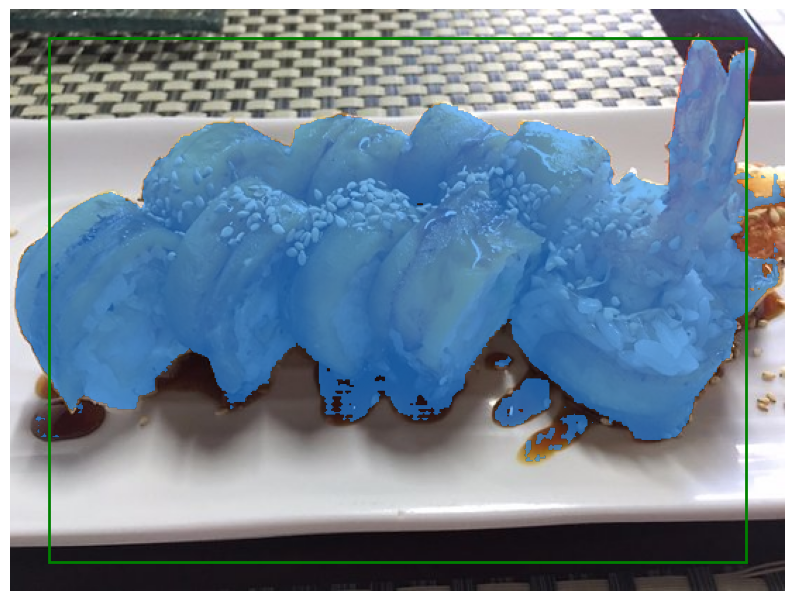

In [99]:
masks, _, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box[None, :],
    multimask_output=True,
)

# print(masks)
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks[0], plt.gca())
show_box(input_box, plt.gca())
plt.axis('off')
plt.show()